<a href="https://colab.research.google.com/github/Shubhbhangoo/Shubhbhangoo/blob/main/research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2

In [2]:
import kagglehub
path = kagglehub.dataset_download("mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images")
print(path)

/root/.cache/kagglehub/datasets/mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images/versions/1


In [ ]:
import os
print(os.listdir(path))


['Challenging Datasets', 'BT-MRI Dataset']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
DATASET_PATH="/kaggle/input/mri-brain-tumor-dataset-4-class-7023-images"

In [ ]:
IMG_SIZE = 128
CLASSES = ['Glioma','Meningioma','Pituitary','No-tumor']

def load_dataset(base_path):
    X, y = [], []

    for label, cls in enumerate(CLASSES):
        folder = os.path.join(base_path, cls)

        for file in os.listdir(folder):
            path = os.path.join(folder, file)

            img = cv2.imread(path)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            X.append(img)
            y.append(label)

    X = np.array(X, dtype="float32") / 255.0
    y = np.array(y)

    return X, y

In [ ]:
TRAIN_PATH = path + "/BT-MRI Dataset/BT-MRI Dataset/Training"
TEST_PATH  = path + "/BT-MRI Dataset/BT-MRI Dataset/Testing"
CHALLENGE_PATH = path + "/BT-MRI Dataset/Challenging Datasets"

In [ ]:
print(os.listdir(path + "/BT-MRI Dataset"))
X_train, y_train = load_dataset(TRAIN_PATH)
X_test, y_test   = load_dataset(TEST_PATH)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


['BT-MRI Dataset']
(5712, 128, 128, 3) (5712,)
(1311, 128, 128, 3) (1311,)


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=8
)

Epoch 1/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 105s 138ms/step - accuracy: 0.8374 - loss: 0.4364 - val_accuracy: 0.8810 - val_loss: 0.3013
Epoch 2/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 136s 130ms/step - accuracy: 0.8979 - loss: 0.2759 - val_accuracy: 0.9039 - val_loss: 0.2479
Epoch 3/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 88s 124ms/step - accuracy: 0.9165 - loss: 0.2225 - val_accuracy: 0.9100 - val_loss: 0.2147
Epoch 4/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 90s 126ms/step - accuracy: 0.9300 - loss: 0.1878 - val_accuracy: 0.9291 - val_loss: 0.1960
Epoch 5/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 89s 125ms/step - accuracy: 0.9424 - loss: 0.1509 - val_accuracy: 0.9291 - val_loss: 0.2160
Epoch 6/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 89s 125ms/step - accuracy: 0.9435 - loss: 0.1498 - val_accuracy: 0.9344 - val_loss: 0.1909
Epoch 7/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 142s 124ms/step - accuracy: 0.9583 - loss: 0.1168 - val_accuracy: 0.9390 - val_loss: 0.1537
Epoch 8/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 88s 123ms/step - accuracy: 0.9613 - loss

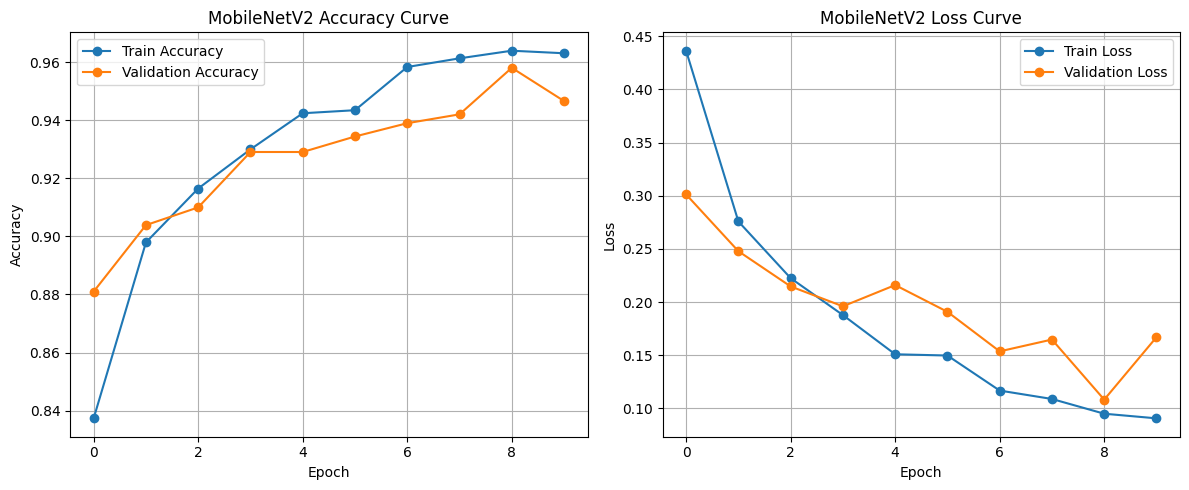

41/41 ━━━━━━━━━━━━━━━━━━━━ 24s 504ms/step
Accuracy : 94.66 %
Precision: 95.13 %
Recall   : 94.66 %
F1 Score : 94.65 %

Classification Report:

              precision    recall  f1-score   support

      glioma       0.98      0.83      0.90       300
  meningioma       0.84      0.97      0.90       306
   pituitary       0.99      0.97      0.98       300
     notumor       0.99      1.00      0.99       405

    accuracy                           0.95      1311
   macro avg       0.95      0.94      0.94      1311
weighted avg       0.95      0.95      0.95      1311



<Figure size 640x480 with 0 Axes>

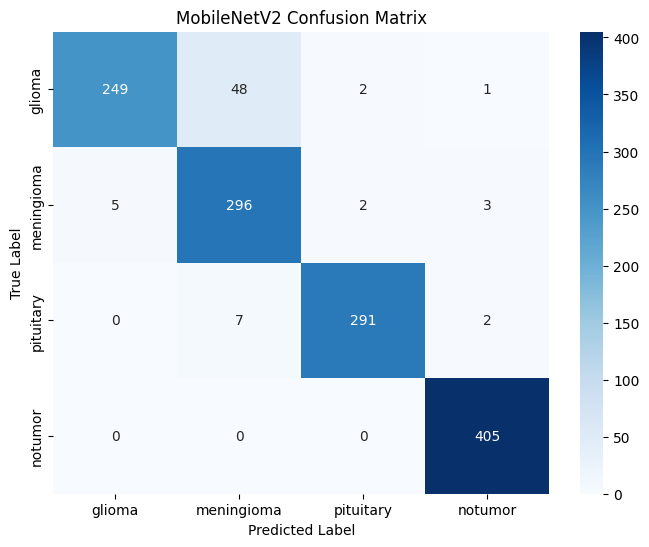

<Figure size 640x480 with 0 Axes>

In [ ]:
# ==========================================
# MobileNetV2 Graphs + Metrics Code
# Run after training is finished
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ==========================================
# 1. Accuracy + Loss Curves
# ==========================================

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')
plt.title('MobileNetV2 Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], marker='o', label='Train Loss')
plt.plot(history.history['val_loss'], marker='o', label='Validation Loss')
plt.title('MobileNetV2 Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Save graph
plt.savefig("mobilenet_curves.png", dpi=300, bbox_inches='tight')


# ==========================================
# 2. Predictions
# ==========================================

y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

# ==========================================
# 3. Metrics
# ==========================================

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", round(acc*100,2), "%")
print("Precision:", round(prec*100,2), "%")
print("Recall   :", round(rec*100,2), "%")
print("F1 Score :", round(f1*100,2), "%")

# ==========================================
# 4. Classification Report
# ==========================================

classes = ['glioma','meningioma','pituitary','notumor']

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=classes))

# ==========================================
# 5. Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Save confusion matrix
plt.savefig("mobilenet_confusion_matrix.png", dpi=300, bbox_inches='tight')

In [ ]:
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras import layers, models

X_train_eff = preprocess_input(X_train.copy()*255.0)
X_test_eff  = preprocess_input(X_test.copy()*255.0)

In [ ]:
base = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base.trainable = False

model_eff = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

model_eff.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_eff.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history_eff = model_eff.fit(
    X_train_eff, y_train,
    validation_data=(X_test_eff, y_test),
    epochs=10,
    batch_size=8
)

Epoch 1/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 181s 236ms/step - accuracy: 0.8071 - loss: 0.5017 - val_accuracy: 0.8490 - val_loss: 0.3953
Epoch 2/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 164s 229ms/step - accuracy: 0.8727 - loss: 0.3320 - val_accuracy: 0.8749 - val_loss: 0.3427
Epoch 3/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 146s 204ms/step - accuracy: 0.9039 - loss: 0.2581 - val_accuracy: 0.9024 - val_loss: 0.2492
Epoch 4/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 146s 204ms/step - accuracy: 0.9174 - loss: 0.2236 - val_accuracy: 0.9153 - val_loss: 0.2249
Epoch 5/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 144s 202ms/step - accuracy: 0.9237 - loss: 0.2016 - val_accuracy: 0.9214 - val_loss: 0.2151
Epoch 6/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 145s 203ms/step - accuracy: 0.9287 - loss: 0.1826 - val_accuracy: 0.9222 - val_loss: 0.1871
Epoch 7/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 206s 208ms/step - accuracy: 0.9391 - loss: 0.1623 - val_accuracy: 0.9321 - val_loss: 0.1683
Epoch 8/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 146s 204ms/step - accuracy: 0.9440 -

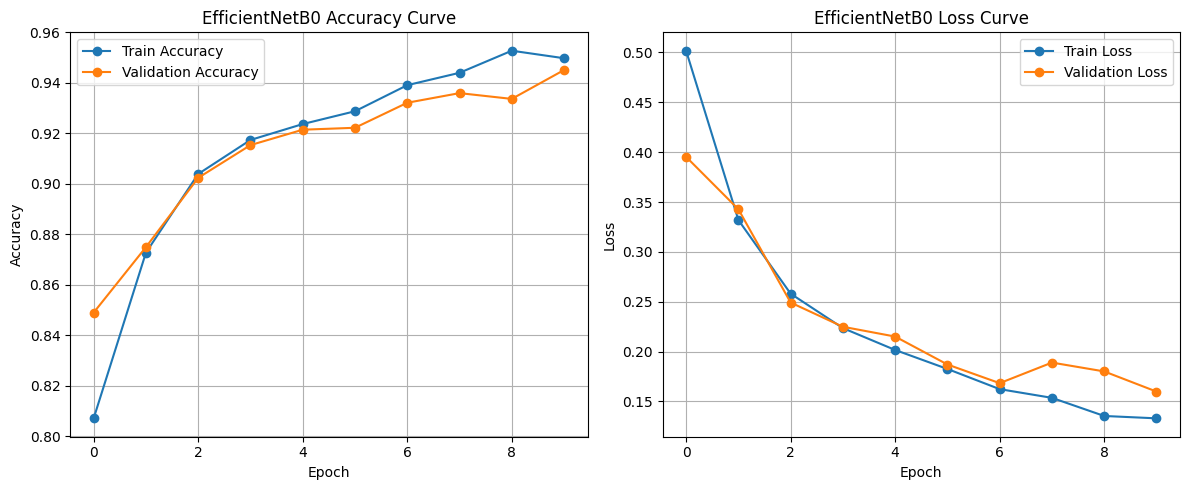

41/41 ━━━━━━━━━━━━━━━━━━━━ 34s 760ms/step
Accuracy : 94.51 %
Precision: 94.49 %
Recall   : 94.51 %
F1 Score : 94.47 %

Classification Report:

              precision    recall  f1-score   support

      glioma       0.93      0.88      0.90       300
  meningioma       0.90      0.91      0.90       306
   pituitary       0.95      0.99      0.97       300
     notumor       0.99      0.99      0.99       405

    accuracy                           0.95      1311
   macro avg       0.94      0.94      0.94      1311
weighted avg       0.94      0.95      0.94      1311



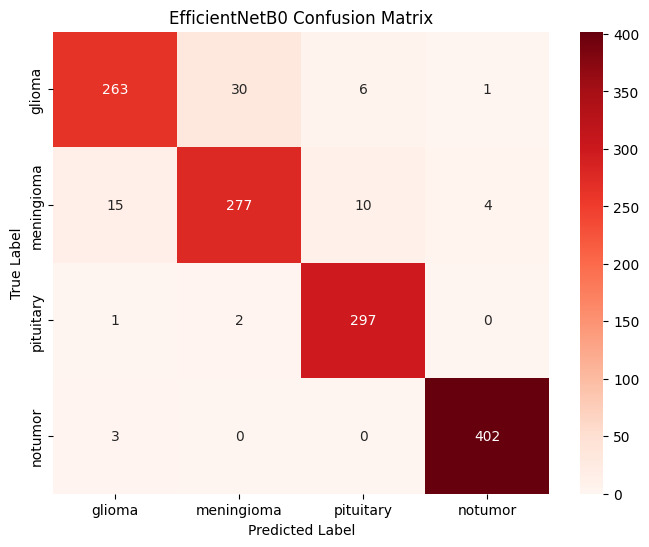

<Figure size 640x480 with 0 Axes>

In [ ]:
# ==========================================
# EfficientNetB0 Metrics + Graphs + Heatmap
# Run after training completed
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ==========================================
# 1. Accuracy + Loss Curves
# ==========================================

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_eff.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history_eff.history['val_accuracy'], marker='o', label='Validation Accuracy')
plt.title('EfficientNetB0 Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history_eff.history['loss'], marker='o', label='Train Loss')
plt.plot(history_eff.history['val_loss'], marker='o', label='Validation Loss')
plt.title('EfficientNetB0 Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 2. Predictions
# ==========================================

y_prob = model_eff.predict(X_test_eff)
y_pred = np.argmax(y_prob, axis=1)

# ==========================================
# 3. Metrics
# ==========================================

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", round(acc*100,2), "%")
print("Precision:", round(prec*100,2), "%")
print("Recall   :", round(rec*100,2), "%")
print("F1 Score :", round(f1*100,2), "%")

# ==========================================
# 4. Classification Report
# ==========================================

classes = ['glioma','meningioma','pituitary','notumor']

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=classes))

# ==========================================
# 5. Confusion Matrix Heatmap
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=classes,
    yticklabels=classes
)

plt.title("EfficientNetB0 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ==========================================
# 6. Save Figures
# ==========================================

plt.savefig("efficientnet_confusion_matrix.png", dpi=300, bbox_inches='tight')

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# Preprocess for ResNet
X_train_res = preprocess_input(X_train.copy() * 255.0)
X_test_res  = preprocess_input(X_test.copy() * 255.0)

# Base model
base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base.trainable = False

# Build model
model_res = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

# Compile
model_res.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
model_res.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history_res = model_res.fit(
    X_train_res, y_train,
    validation_data=(X_test_res, y_test),
    epochs=10,
    batch_size=8
)

Epoch 1/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 414s 566ms/step - accuracy: 0.8023 - loss: 0.5160 - val_accuracy: 0.8490 - val_loss: 0.3662
Epoch 2/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 440s 563ms/step - accuracy: 0.8825 - loss: 0.3221 - val_accuracy: 0.8741 - val_loss: 0.3184
Epoch 3/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 439s 559ms/step - accuracy: 0.9048 - loss: 0.2572 - val_accuracy: 0.8871 - val_loss: 0.2725
Epoch 4/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 399s 559ms/step - accuracy: 0.9153 - loss: 0.2247 - val_accuracy: 0.8818 - val_loss: 0.3270
Epoch 5/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 393s 550ms/step - accuracy: 0.9221 - loss: 0.2032 - val_accuracy: 0.9268 - val_loss: 0.2094
Epoch 6/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 456s 569ms/step - accuracy: 0.9336 - loss: 0.1734 - val_accuracy: 0.9115 - val_loss: 0.2489
Epoch 7/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 396s 554ms/step - accuracy: 0.9363 - loss: 0.1656 - val_accuracy: 0.9260 - val_loss: 0.2049
Epoch 8/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 403s 565ms/step - accuracy: 0.9419 -

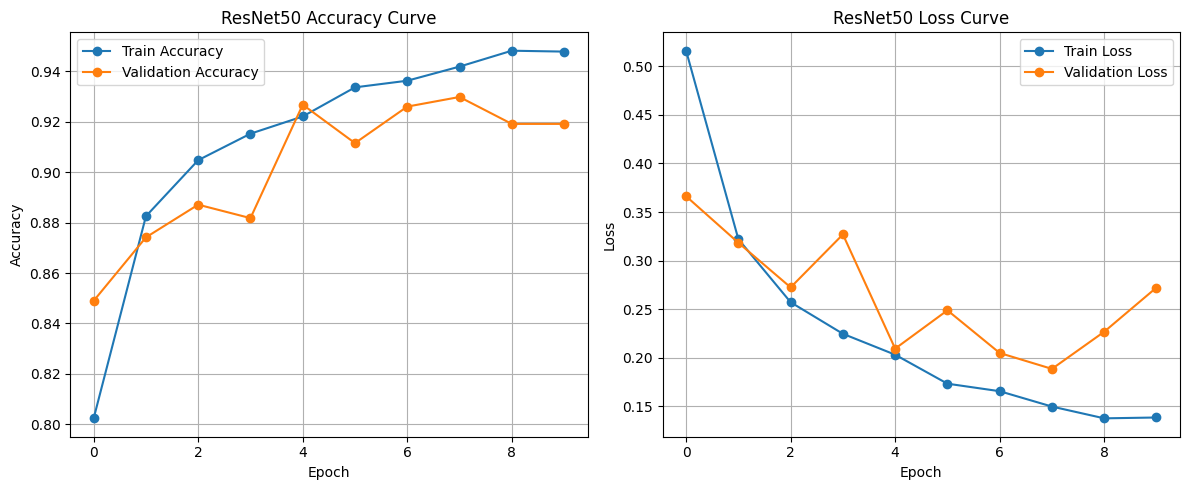

41/41 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step
Accuracy : 91.91 %
Precision: 92.88 %
Recall   : 91.91 %
F1 Score : 91.85 %

Classification Report:

              precision    recall  f1-score   support

      glioma       0.98      0.75      0.85       300
  meningioma       0.79      0.95      0.86       306
   pituitary       0.93      0.97      0.95       300
     notumor       1.00      0.99      0.99       405

    accuracy                           0.92      1311
   macro avg       0.92      0.91      0.91      1311
weighted avg       0.93      0.92      0.92      1311



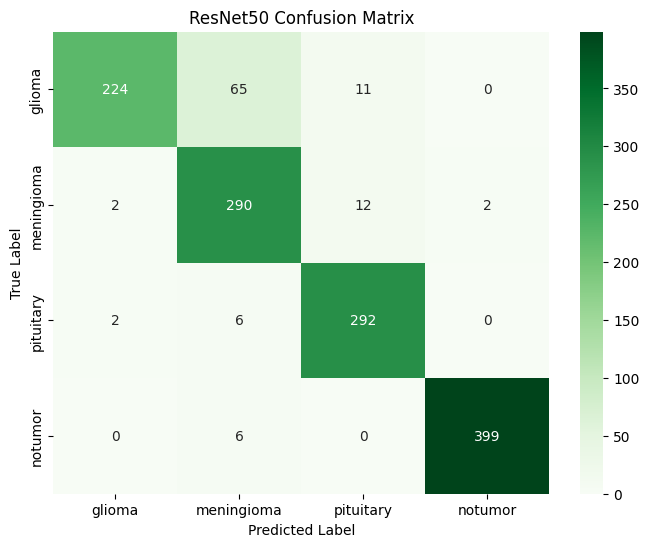

In [ ]:
# ==========================================
# ResNet50 Metrics + Graphs + Heatmap
# Run after training completed
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ==========================================
# 1. Accuracy + Loss Curves
# ==========================================

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_res.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history_res.history['val_accuracy'], marker='o', label='Validation Accuracy')
plt.title('ResNet50 Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history_res.history['loss'], marker='o', label='Train Loss')
plt.plot(history_res.history['val_loss'], marker='o', label='Validation Loss')
plt.title('ResNet50 Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 2. Predictions
# ==========================================

y_prob = model_res.predict(X_test_res)
y_pred = np.argmax(y_prob, axis=1)

# ==========================================
# 3. Metrics
# ==========================================

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", round(acc*100,2), "%")
print("Precision:", round(prec*100,2), "%")
print("Recall   :", round(rec*100,2), "%")
print("F1 Score :", round(f1*100,2), "%")

# ==========================================
# 4. Classification Report
# ==========================================

classes = ['glioma','meningioma','pituitary','notumor']

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=classes))

# ==========================================
# 5. Confusion Matrix Heatmap
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=classes,
    yticklabels=classes
)

plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping

model_cnn = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(4, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,568,708 (5.98 MB)

 Trainable params: 1,568,708 (5.98 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=8,
    callbacks=[
        EarlyStopping(
            monitor='val_accuracy',
            patience=2,
            restore_best_weights=True
        )
    ]
)

Epoch 1/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 233s 319ms/step - accuracy: 0.6963 - loss: 0.7226 - val_accuracy: 0.7818 - val_loss: 0.5345
Epoch 2/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 220s 307ms/step - accuracy: 0.8398 - loss: 0.4298 - val_accuracy: 0.8391 - val_loss: 0.4224
Epoch 3/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 262s 308ms/step - accuracy: 0.8817 - loss: 0.3229 - val_accuracy: 0.8825 - val_loss: 0.3097
Epoch 4/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 266s 314ms/step - accuracy: 0.9146 - loss: 0.2395 - val_accuracy: 0.8963 - val_loss: 0.3183
Epoch 5/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 226s 317ms/step - accuracy: 0.9289 - loss: 0.1976 - val_accuracy: 0.8978 - val_loss: 0.2713
Epoch 6/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 253s 305ms/step - accuracy: 0.9440 - loss: 0.1531 - val_accuracy: 0.9252 - val_loss: 0.2155
Epoch 7/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 270s 315ms/step - accuracy: 0.9519 - loss: 0.1320 - val_accuracy: 0.9298 - val_loss: 0.2116
Epoch 8/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 226s 317ms/step - accuracy: 0.9615 -

41/41 ━━━━━━━━━━━━━━━━━━━━ 16s 389ms/step
Accuracy : 94.36 %
Precision: 94.46 %
Recall   : 94.36 %
F1 Score : 94.31 %
              precision    recall  f1-score   support

      glioma       0.99      0.88      0.93       300
  meningioma       0.88      0.88      0.88       306
   pituitary       0.98      0.99      0.98       300
     notumor       0.94      1.00      0.97       405

    accuracy                           0.94      1311
   macro avg       0.95      0.94      0.94      1311
weighted avg       0.94      0.94      0.94      1311



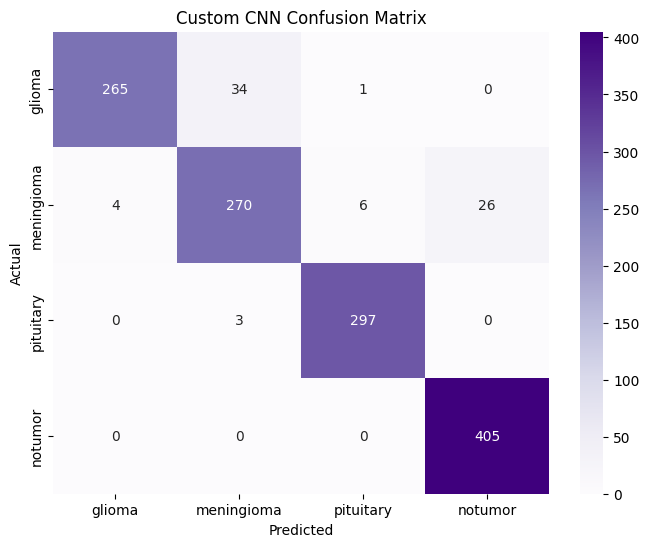

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_prob = model_cnn.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

# Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", round(acc*100,2), "%")
print("Precision:", round(prec*100,2), "%")
print("Recall   :", round(rec*100,2), "%")
print("F1 Score :", round(f1*100,2), "%")

classes = ['glioma','meningioma','pituitary','notumor']
print(classification_report(y_test, y_pred, target_names=classes))

# Heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=classes, yticklabels=classes)
plt.title("Custom CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

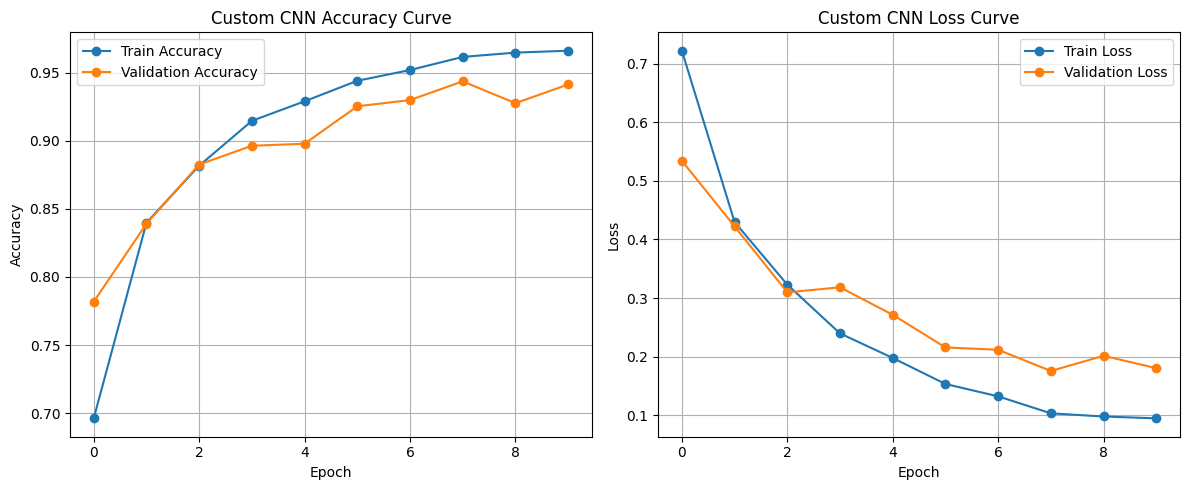

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy Graph
plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], marker='o', label='Validation Accuracy')

plt.title("Custom CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss Graph
plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], marker='o', label='Train Loss')
plt.plot(history_cnn.history['val_loss'], marker='o', label='Validation Loss')

plt.title("Custom CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

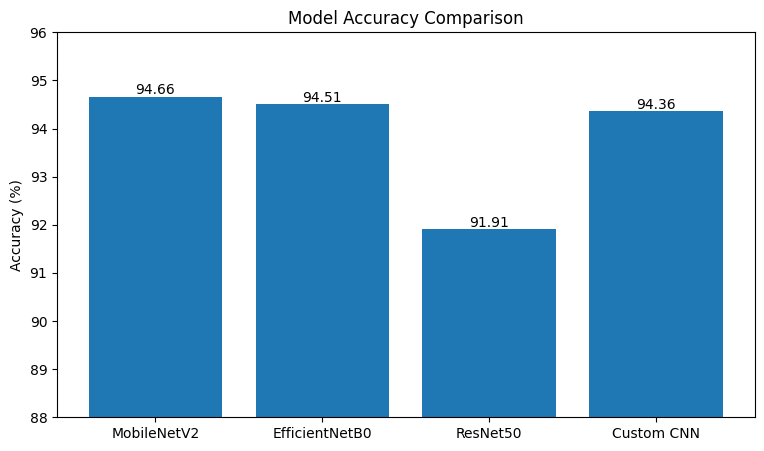

In [ ]:
import matplotlib.pyplot as plt

models = ['MobileNetV2', 'EfficientNetB0', 'ResNet50', 'Custom CNN']
acc = [94.66, 94.51, 91.91, 94.36]

plt.figure(figsize=(9,5))
bars = plt.bar(models, acc)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(88,96)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y+0.05, round(y,2),
             ha='center')

plt.show()

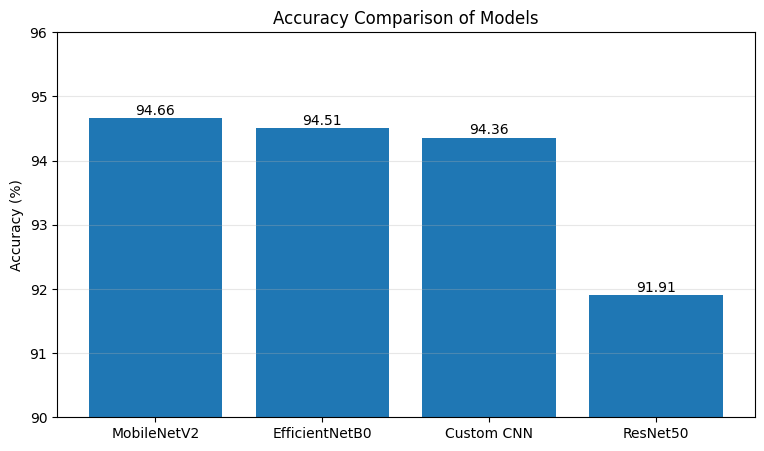

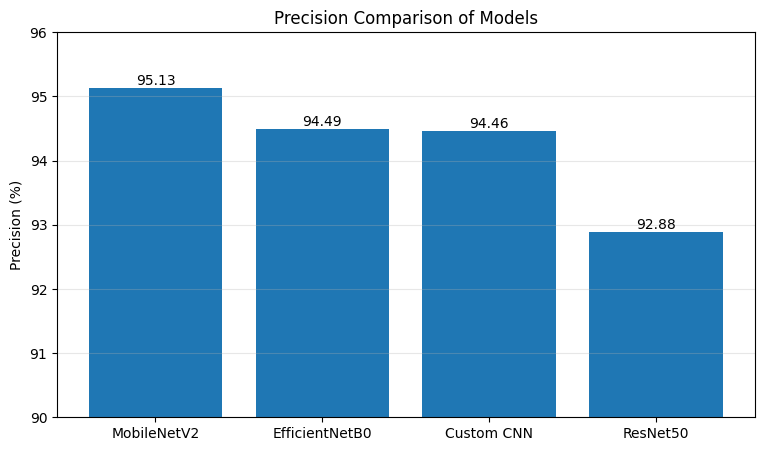

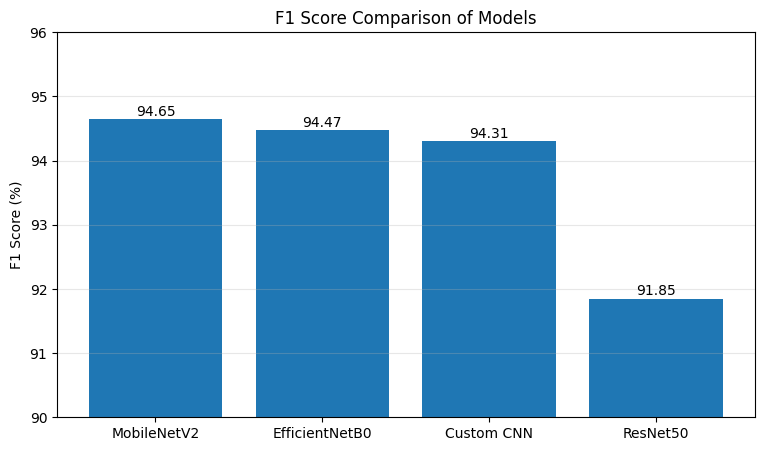

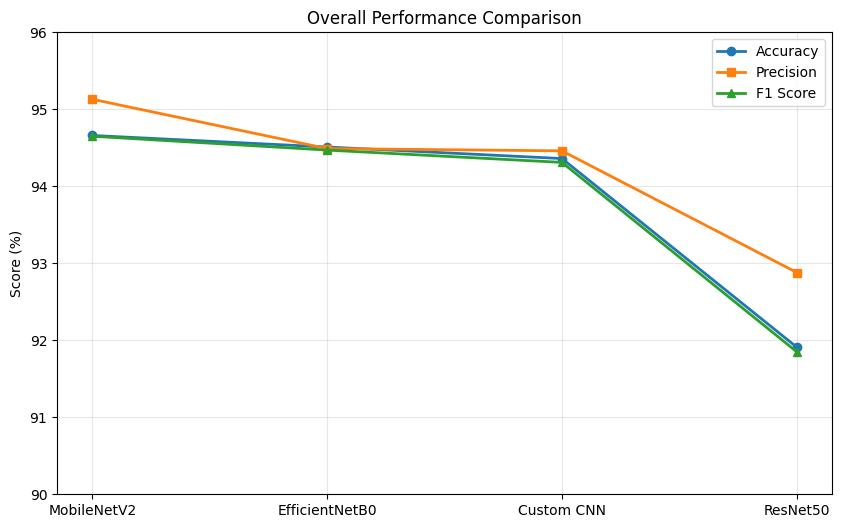

In [ ]:
# ==========================================
# Combined Comparison Graphs (All Models)
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

models = ['MobileNetV2', 'EfficientNetB0', 'Custom CNN', 'ResNet50']

accuracy  = [94.66, 94.51, 94.36, 91.91]
precision = [95.13, 94.49, 94.46, 92.88]
f1_score  = [94.65, 94.47, 94.31, 91.85]

# ==========================================
# 1. Accuracy Comparison
# ==========================================

plt.figure(figsize=(9,5))
bars = plt.bar(models, accuracy)

plt.title("Accuracy Comparison of Models")
plt.ylabel("Accuracy (%)")
plt.ylim(90, 96)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y+0.05,
             f'{y:.2f}', ha='center')

plt.grid(axis='y', alpha=0.3)
plt.show()

# ==========================================
# 2. Precision Comparison
# ==========================================

plt.figure(figsize=(9,5))
bars = plt.bar(models, precision)

plt.title("Precision Comparison of Models")
plt.ylabel("Precision (%)")
plt.ylim(90, 96)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y+0.05,
             f'{y:.2f}', ha='center')

plt.grid(axis='y', alpha=0.3)
plt.show()

# ==========================================
# 3. F1 Score Comparison
# ==========================================

plt.figure(figsize=(9,5))
bars = plt.bar(models, f1_score)

plt.title("F1 Score Comparison of Models")
plt.ylabel("F1 Score (%)")
plt.ylim(90, 96)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y+0.05,
             f'{y:.2f}', ha='center')

plt.grid(axis='y', alpha=0.3)
plt.show()

# ==========================================
# 4. Combined Multi-Line Graph
# ==========================================

x = np.arange(len(models))

plt.figure(figsize=(10,6))
plt.plot(x, accuracy, marker='o', linewidth=2, label='Accuracy')
plt.plot(x, precision, marker='s', linewidth=2, label='Precision')
plt.plot(x, f1_score, marker='^', linewidth=2, label='F1 Score')

plt.xticks(x, models)
plt.ylabel("Score (%)")
plt.title("Overall Performance Comparison")
plt.ylim(90,96)

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import os
import cv2
import numpy as np
from sklearn.metrics import accuracy_score

from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

base_path = "/kaggle/input/mri-brain-tumor-dataset-4-class-7023-images/Challenging Datasets/Challenging Datasets"

classes = ['Glioma', 'Meningioma', 'Pituitary', 'No-tumor']
label_map = {name:i for i,name in enumerate(classes)}

types = ['Blurred Dataset', 'Noisy Dataset', 'Patient Motion Artifact Dataset']

IMG_SIZE = 128

def load_folder(folder_path):
    X, y = [], []

    for cls in classes:
        class_path = os.path.join(folder_path, cls)

        for img in os.listdir(class_path):
            img_path = os.path.join(class_path, img)

            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (128,128))
            image = image / 255.0

            X.append(image)
            y.append(label_map[cls])

    return np.array(X), np.array(y)

for t in types:

    print("\n======", t.upper(), "======")

    folder = os.path.join(base_path, t)
    X_ch, y_ch = load_folder(folder)

    # MobileNetV2
    pred = np.argmax(model.predict(X_ch), axis=1)
    print("MobileNetV2 :", round(accuracy_score(y_ch, pred)*100,2), "%")

    # EfficientNet FIXED
    X_eff = eff_preprocess(X_ch.copy() * 255.0)
    pred = np.argmax(model_eff.predict(X_eff), axis=1)
    print("EfficientNet:", round(accuracy_score(y_ch, pred)*100,2), "%")

    # Custom CNN
    pred = np.argmax(model_cnn.predict(X_ch), axis=1)
    print("Custom CNN  :", round(accuracy_score(y_ch, pred)*100,2), "%")

    # ResNet50
    X_res = resnet_preprocess(X_ch.copy() * 255.0)
    pred = np.argmax(model_res.predict(X_res), axis=1)
    print("ResNet50    :", round(accuracy_score(y_ch, pred)*100,2), "%")


====== BLURRED DATASET ======
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 366ms/step
MobileNetV2 : 81.16 %
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 655ms/step
EfficientNet: 88.43 %
53/53 ━━━━━━━━━━━━━━━━━━━━ 17s 317ms/step
Custom CNN  : 97.56 %
53/53 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step
ResNet50    : 82.35 %

====== NOISY DATASET ======
53/53 ━━━━━━━━━━━━━━━━━━━━ 22s 411ms/step
MobileNetV2 : 73.82 %
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 652ms/step
EfficientNet: 73.52 %
53/53 ━━━━━━━━━━━━━━━━━━━━ 17s 314ms/step
Custom CNN  : 72.27 %
53/53 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step
ResNet50    : 70.72 %

====== PATIENT MOTION ARTIFACT DATASET ======
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 326ms/step
MobileNetV2 : 65.12 %
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 644ms/step
EfficientNet: 72.27 %
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 271ms/step
Custom CNN  : 67.26 %
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step
ResNet50    : 64.04 %


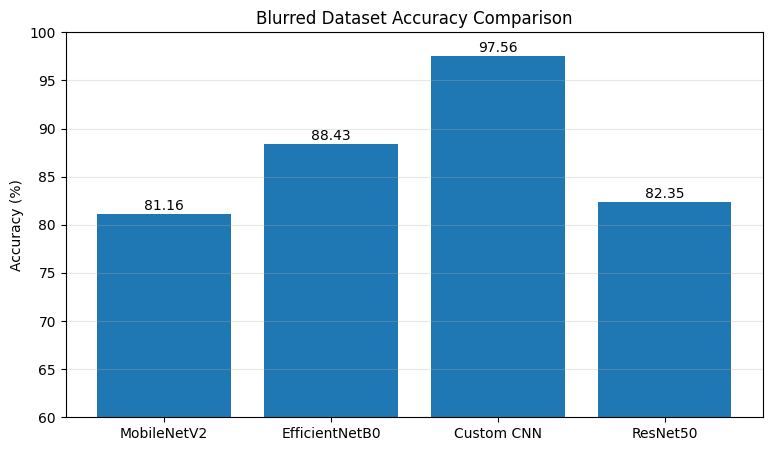

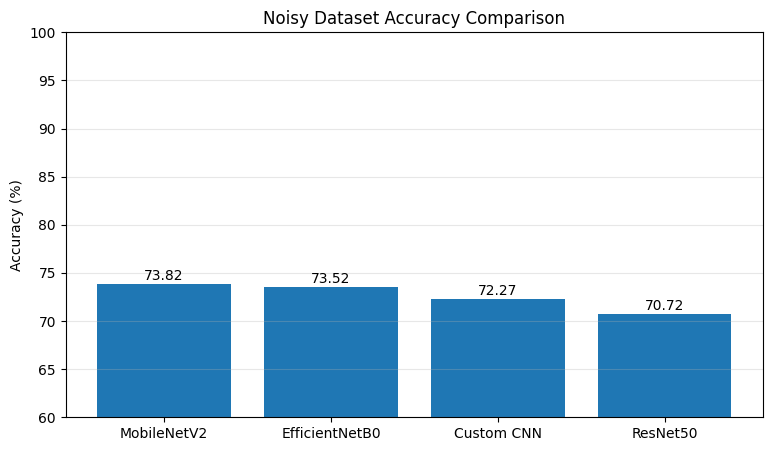

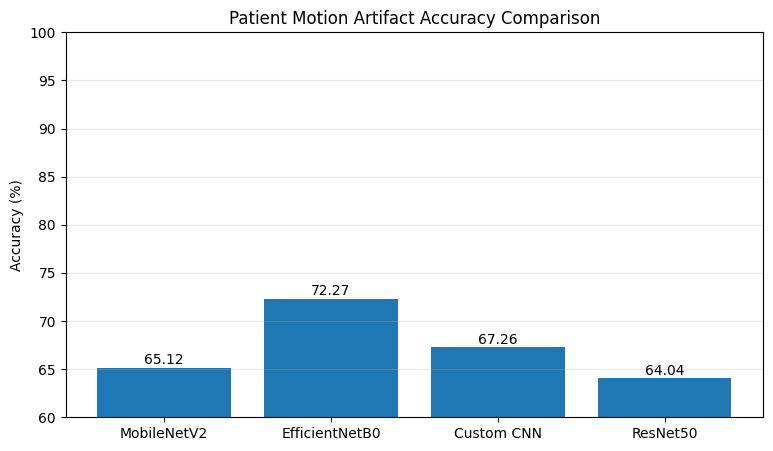

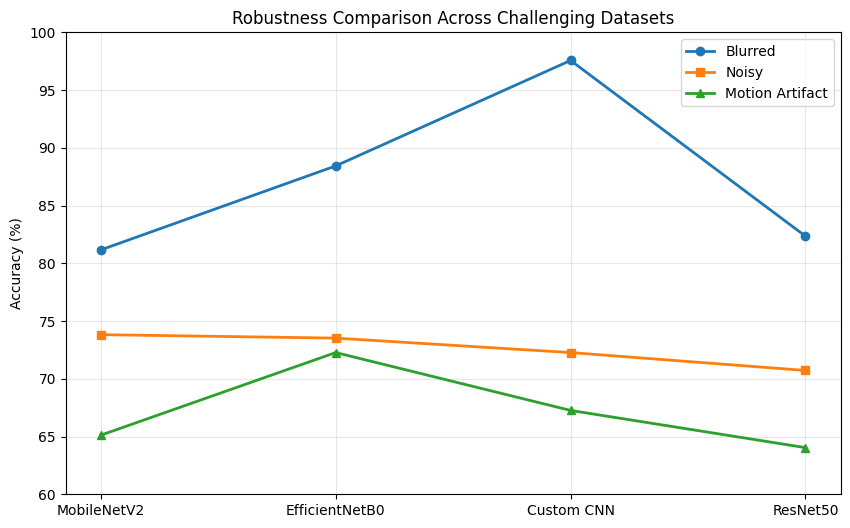

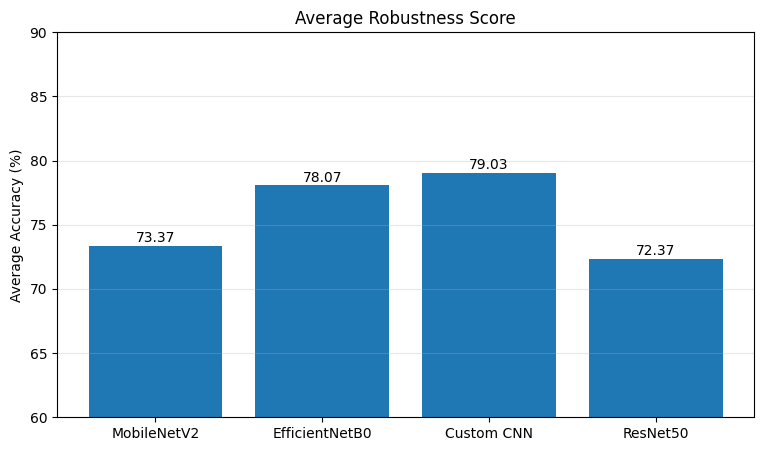

In [ ]:
# ==========================================
# Challenging Dataset Robustness Graphs
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

models = ['MobileNetV2', 'EfficientNetB0', 'Custom CNN', 'ResNet50']

blurred = [81.16, 88.43, 97.56, 82.35]
noisy   = [73.82, 73.52, 72.27, 70.72]
motion  = [65.12, 72.27, 67.26, 64.04]

# ==========================================
# 1. Blurred Dataset Comparison
# ==========================================

plt.figure(figsize=(9,5))
bars = plt.bar(models, blurred)

plt.title("Blurred Dataset Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(60,100)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y+0.4, f'{y:.2f}', ha='center')

plt.grid(axis='y', alpha=0.3)
plt.show()

# ==========================================
# 2. Noisy Dataset Comparison
# ==========================================

plt.figure(figsize=(9,5))
bars = plt.bar(models, noisy)

plt.title("Noisy Dataset Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(60,100)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y+0.4, f'{y:.2f}', ha='center')

plt.grid(axis='y', alpha=0.3)
plt.show()

# ==========================================
# 3. Motion Artifact Comparison
# ==========================================

plt.figure(figsize=(9,5))
bars = plt.bar(models, motion)

plt.title("Patient Motion Artifact Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(60,100)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y+0.4, f'{y:.2f}', ha='center')

plt.grid(axis='y', alpha=0.3)
plt.show()

# ==========================================
# 4. Combined Multi-Line Robustness Graph
# ==========================================

x = np.arange(len(models))

plt.figure(figsize=(10,6))
plt.plot(x, blurred, marker='o', linewidth=2, label='Blurred')
plt.plot(x, noisy, marker='s', linewidth=2, label='Noisy')
plt.plot(x, motion, marker='^', linewidth=2, label='Motion Artifact')

plt.xticks(x, models)
plt.ylabel("Accuracy (%)")
plt.title("Robustness Comparison Across Challenging Datasets")
plt.ylim(60,100)

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 5. Average Challenging Accuracy
# ==========================================

avg = [
    (81.16+73.82+65.12)/3,
    (88.43+73.52+72.27)/3,
    (97.56+72.27+67.26)/3,
    (82.35+70.72+64.04)/3
]

plt.figure(figsize=(9,5))
bars = plt.bar(models, avg)

plt.title("Average Robustness Score")
plt.ylabel("Average Accuracy (%)")
plt.ylim(60,90)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y+0.3, f'{y:.2f}', ha='center')

plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
model.save("MobileNetV2_model.keras")
model_eff.save("EfficientNetB0_model.keras")
model_res.save("ResNet50_model.keras")
model_cnn.save("CustomCNN_model.keras")

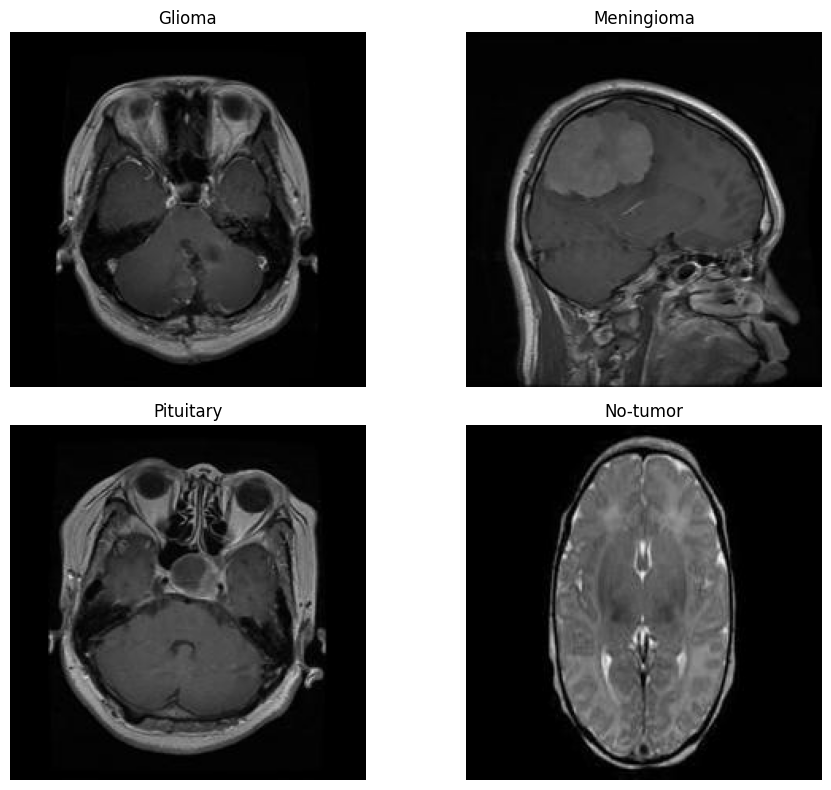

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

base_path = "/kaggle/input/mri-brain-tumor-dataset-4-class-7023-images/BT-MRI Dataset/BT-MRI Dataset/Testing"

classes = ['Glioma', 'Meningioma', 'Pituitary', 'No-tumor']

plt.figure(figsize=(10,8))

for i, cls in enumerate(classes):
    folder = os.path.join(base_path, cls)
    img_name = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.savefig("dataset_classes.png", dpi=300)
plt.show()

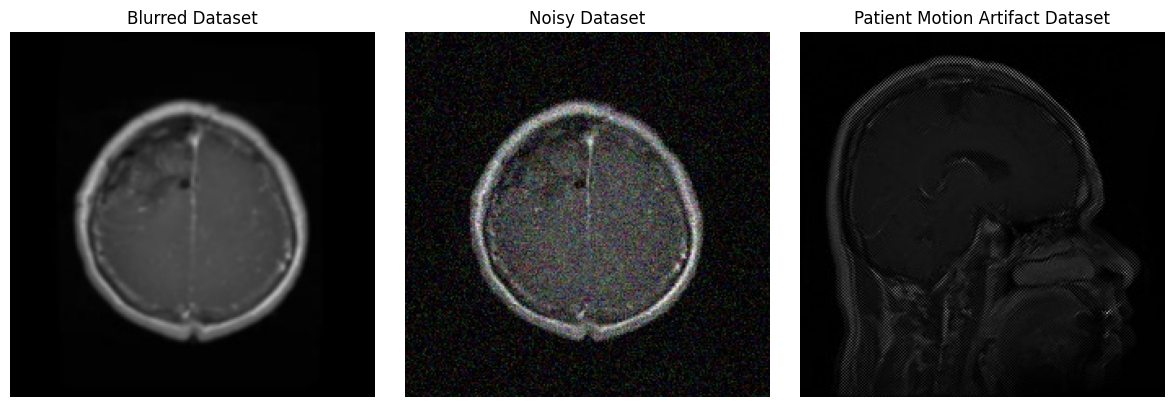

In [ ]:
base_path = "/kaggle/input/mri-brain-tumor-dataset-4-class-7023-images/Challenging Datasets/Challenging Datasets"

folders = ['Blurred Dataset', 'Noisy Dataset', 'Patient Motion Artifact Dataset']

plt.figure(figsize=(12,4))

for i, f in enumerate(folders):
    cls_folder = os.path.join(base_path, f, 'Glioma')
    img_name = os.listdir(cls_folder)[0]
    img_path = os.path.join(cls_folder, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(f)
    plt.axis('off')

plt.tight_layout()
plt.savefig("challenging_samples.png", dpi=300)
plt.show()

In [13]:
!pip install tf-keras-vis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 2.8 MB/s eta 0:00:00


In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.scores import CategoricalScore
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear

MODEL_PATH = "/content/MobileNetV2_model.keras"
IMG_PATH = "/root/.cache/kagglehub/datasets/mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images/versions/1/Challenging Datasets/Challenging Datasets/Blurred Dataset/Glioma/bilateral_glioma (1).jpg"

CLASS_NAMES = ["Glioma","Meningioma","Pituitary","No Tumour"]
IMG_SIZE = (128,128)

# load model
model = load_model(MODEL_PATH)

# image
img = image.load_img(IMG_PATH, target_size=IMG_SIZE)
x = image.img_to_array(img)/255.0
x = np.expand_dims(x, axis=0)

# predict
pred = model.predict(x, verbose=0)
idx = np.argmax(pred[0])

# gradcam
gradcam = Gradcam(model,
                  model_modifier=ReplaceToLinear(),
                  clone=True)

cam = gradcam(
    CategoricalScore(idx),
    x,
    penultimate_layer=-1
)

heatmap = cam[0]

# overlay
orig = cv2.imread(IMG_PATH)
orig = cv2.resize(orig, IMG_SIZE)
heat = np.uint8(255 * heatmap)
heat = cv2.applyColorMap(heat, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(orig, 0.6, heat, 0.4, 0)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"{CLASS_NAMES[idx]} ({pred[0][idx]:.2f})")
plt.axis("off")
plt.show()

AttributeError: 'Sequential' object has no attribute 'output_names'

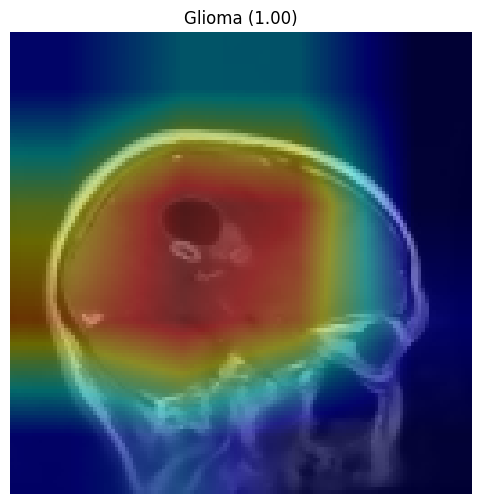

In [16]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

MODEL_PATH = "/content/MobileNetV2_model.keras"
IMG_PATH = "/root/.cache/kagglehub/datasets/mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images/versions/1/Challenging Datasets/Challenging Datasets/Blurred Dataset/Glioma/bilateral_glioma (1).jpg"

CLASS_NAMES = ["Glioma","Meningioma","Pituitary","No-tumor"]
IMG_SIZE = (128,128)

# load trained model
model = load_model(MODEL_PATH)

# split parts
base = model.layers[0]   # MobileNetV2
gap = model.layers[1]
dense1 = model.layers[2]
drop = model.layers[3]
dense2 = model.layers[4]

# image
img = image.load_img(IMG_PATH, target_size=IMG_SIZE)
x = image.img_to_array(img)/255.0
x = np.expand_dims(x,0).astype(np.float32)

with tf.GradientTape() as tape:
    # forward through backbone
    feat_maps = base(x, training=False)

    tape.watch(feat_maps)

    # forward classifier head
    y = gap(feat_maps)
    y = dense1(y)
    y = drop(y, training=False)
    preds = dense2(y)

    idx = tf.argmax(preds[0])
    loss = preds[:, idx]

# grads wrt final feature maps (4x4x1280)
grads = tape.gradient(loss, feat_maps)

weights = tf.reduce_mean(grads, axis=(1,2))  # global avg pool grads

cam = tf.reduce_sum(
    feat_maps[0] * weights[0][tf.newaxis, tf.newaxis, :],
    axis=-1
)

cam = np.maximum(cam.numpy(), 0)
cam = cam / (cam.max() + 1e-8)

# resize + overlay
orig = cv2.imread(IMG_PATH)
orig = cv2.resize(orig, IMG_SIZE)

heat = cv2.resize(cam, IMG_SIZE)
heat = np.uint8(255 * heat)
heat = cv2.applyColorMap(heat, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(orig, 0.6, heat, 0.4, 0)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"{CLASS_NAMES[int(idx)]} ({float(preds[0][idx]):.2f})")
plt.axis("off")
plt.show()

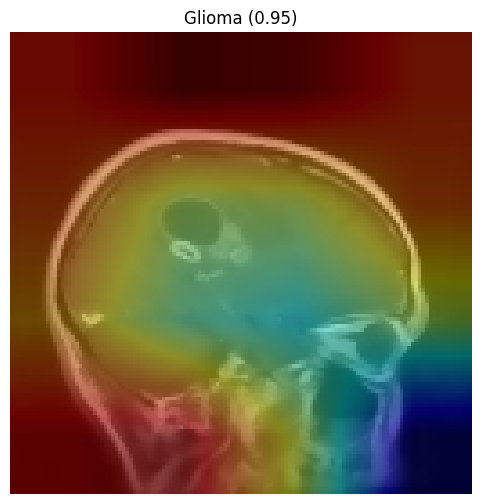

In [17]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

MODEL_PATH = "/content/EfficientNetB0_model.keras"
IMG_PATH = "/root/.cache/kagglehub/datasets/mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images/versions/1/Challenging Datasets/Challenging Datasets/Blurred Dataset/Glioma/bilateral_glioma (1).jpg"

CLASS_NAMES = ["Glioma","Meningioma","Pituitary","No-tumor"]
IMG_SIZE = (128,128)

# load trained model
model = load_model(MODEL_PATH)

# split parts
base = model.layers[0]   # MobileNetV2
gap = model.layers[1]
dense1 = model.layers[2]
drop = model.layers[3]
dense2 = model.layers[4]

# image
img = image.load_img(IMG_PATH, target_size=IMG_SIZE)
x = image.img_to_array(img)/255.0
x = np.expand_dims(x,0).astype(np.float32)

with tf.GradientTape() as tape:
    # forward through backbone
    feat_maps = base(x, training=False)

    tape.watch(feat_maps)

    # forward classifier head
    y = gap(feat_maps)
    y = dense1(y)
    y = drop(y, training=False)
    preds = dense2(y)

    idx = tf.argmax(preds[0])
    loss = preds[:, idx]

# grads wrt final feature maps (4x4x1280)
grads = tape.gradient(loss, feat_maps)

weights = tf.reduce_mean(grads, axis=(1,2))  # global avg pool grads

cam = tf.reduce_sum(
    feat_maps[0] * weights[0][tf.newaxis, tf.newaxis, :],
    axis=-1
)

cam = np.maximum(cam.numpy(), 0)
cam = cam / (cam.max() + 1e-8)

# resize + overlay
orig = cv2.imread(IMG_PATH)
orig = cv2.resize(orig, IMG_SIZE)

heat = cv2.resize(cam, IMG_SIZE)
heat = np.uint8(255 * heat)
heat = cv2.applyColorMap(heat, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(orig, 0.6, heat, 0.4, 0)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"{CLASS_NAMES[int(idx)]} ({float(preds[0][idx]):.2f})")
plt.axis("off")
plt.show()

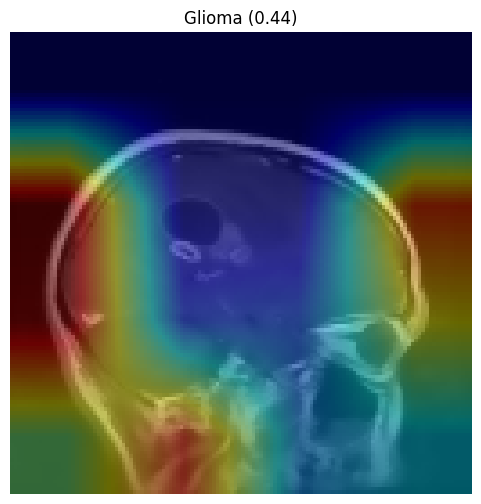

In [18]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

MODEL_PATH = "/content/ResNet50_model.keras"
IMG_PATH = "/root/.cache/kagglehub/datasets/mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images/versions/1/Challenging Datasets/Challenging Datasets/Blurred Dataset/Glioma/bilateral_glioma (1).jpg"

CLASS_NAMES = ["Glioma","Meningioma","Pituitary","No Tumour"]
IMG_SIZE = (128,128)

# load trained model
model = load_model(MODEL_PATH)

# split layers
base = model.layers[0]
gap = model.layers[1]
dense1 = model.layers[2]
drop = model.layers[3]
dense2 = model.layers[4]

# image
img = image.load_img(IMG_PATH, target_size=IMG_SIZE)
x = image.img_to_array(img)/255.0
x = np.expand_dims(x,0).astype(np.float32)

with tf.GradientTape() as tape:

    feat_maps = base(x, training=False)
    tape.watch(feat_maps)

    y = gap(feat_maps)
    y = dense1(y)
    y = drop(y, training=False)
    preds = dense2(y)

    idx = tf.argmax(preds[0])
    loss = preds[:, idx]

grads = tape.gradient(loss, feat_maps)

weights = tf.reduce_mean(grads, axis=(1,2))

cam = tf.reduce_sum(
    feat_maps[0] * weights[0][tf.newaxis, tf.newaxis, :],
    axis=-1
)

cam = np.maximum(cam.numpy(), 0)
cam = cam / (cam.max() + 1e-8)

# overlay
orig = cv2.imread(IMG_PATH)
orig = cv2.resize(orig, IMG_SIZE)

heat = cv2.resize(cam, IMG_SIZE)
heat = np.uint8(255 * heat)
heat = cv2.applyColorMap(heat, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(orig, 0.6, heat, 0.4, 0)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"{CLASS_NAMES[int(idx)]} ({float(preds[0][idx]):.2f})")
plt.axis("off")
plt.show()

Using: conv2d_3


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_8']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


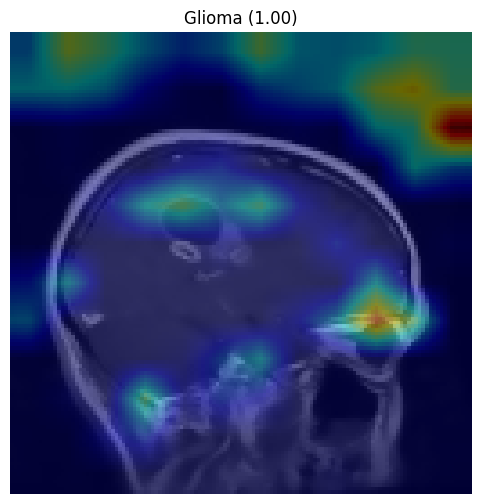

In [19]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

MODEL_PATH = "/content/CustomCNN_model.keras"
IMG_PATH = "/root/.cache/kagglehub/datasets/mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images/versions/1/Challenging Datasets/Challenging Datasets/Blurred Dataset/Glioma/bilateral_glioma (1).jpg"

CLASS_NAMES = ["Glioma","Meningioma","Pituitary","No Tumour"]
IMG_SIZE = (128,128)

# load model
model = load_model(MODEL_PATH)

# image
img = image.load_img(IMG_PATH, target_size=IMG_SIZE)
x = image.img_to_array(img)/255.0
x = np.expand_dims(x,0).astype(np.float32)

# find last Conv2D layer
last_conv = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv = layer
        break

print("Using:", last_conv.name)

# split model
feature_extractor = tf.keras.Model(
    inputs=model.inputs,
    outputs=last_conv.output
)

# classifier after conv layer
classifier_input = tf.keras.Input(shape=last_conv.output.shape[1:])
z = classifier_input

start = False
for layer in model.layers:
    if start:
        z = layer(z)
    if layer.name == last_conv.name:
        start = True

classifier = tf.keras.Model(classifier_input, z)

with tf.GradientTape() as tape:

    feat_maps = feature_extractor(x)
    tape.watch(feat_maps)

    preds = classifier(feat_maps)

    idx = tf.argmax(preds[0])
    loss = preds[:, idx]

grads = tape.gradient(loss, feat_maps)

weights = tf.reduce_mean(grads, axis=(1,2))

cam = tf.reduce_sum(
    feat_maps[0] * weights[0][tf.newaxis, tf.newaxis, :],
    axis=-1
)

cam = np.maximum(cam.numpy(), 0)
cam = cam / (cam.max() + 1e-8)

# overlay
orig = cv2.imread(IMG_PATH)
orig = cv2.resize(orig, IMG_SIZE)

heat = cv2.resize(cam, IMG_SIZE)
heat = np.uint8(255*heat)
heat = cv2.applyColorMap(heat, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(orig, 0.6, heat, 0.4, 0)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"{CLASS_NAMES[int(idx)]} ({float(preds[0][idx]):.2f})")
plt.axis("off")
plt.show()